In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv(r"..\Dataset\dataset_module_one_DM2.csv")

## CBLOF

In [64]:
from pyod.models.cblof import CBLOF
from sklearn.preprocessing import StandardScaler

In [65]:
X = df.values
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [66]:
clf = CBLOF(contamination=0.1)
clf.fit(X)

,n_clusters,8
,contamination,0.1
,clustering_estimator,None
,alpha,0.9
,beta,5
,use_weights,False
,check_estimator,False
,random_state,None
,n_jobs,None


In [67]:
outliers_cblof = clf.predict(X)
np.unique(outliers_cblof, return_counts=True)

(array([0, 1]), array([7107,  790]))

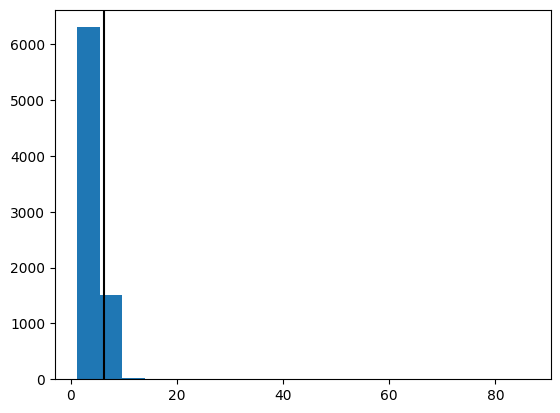

In [68]:
plt.hist(clf.decision_scores_, bins=20)
plt.axvline(np.min(clf.decision_scores_[np.where(outliers_cblof==1)]), c='k')
plt.show()

## Isolation Forest

In [69]:
from pyod.models.iforest import IsolationForest

In [70]:
clf = IsolationForest(contamination=0.1)
clf.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [71]:
outliers_if = clf.predict(X)
np.unique(outliers_if, return_counts=True)

(array([-1,  1]), array([ 790, 7107]))

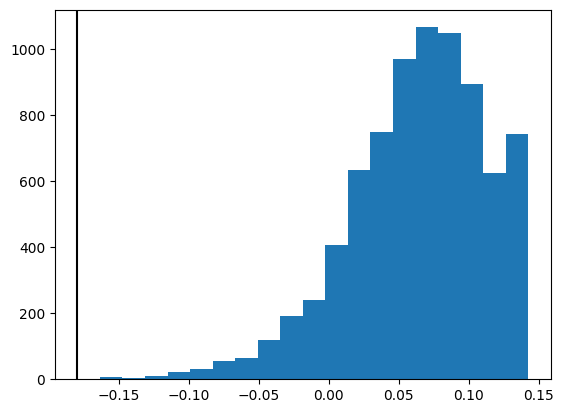

In [72]:
plt.hist(clf.decision_function(X), bins=20)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers_if==-1)]), c='k')
plt.show()

## ABOD

In [73]:
from pyod.models.abod import ABOD

In [74]:
clf = ABOD(contamination=0.1)
clf.fit(X)

,contamination,0.1
,n_neighbors,5
,method,'fast'
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,1


In [75]:
outliers_abod = clf.predict(X)
np.unique(outliers_abod, return_counts=True)

(array([0, 1]), array([7107,  790]))

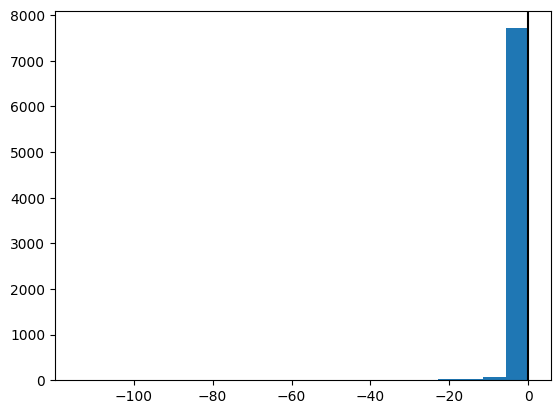

In [76]:
plt.hist(clf.decision_scores_, bins=20)
plt.axvline(np.min(clf.decision_scores_[np.where(outliers_abod==1)]), c='k')
plt.show()

### Verifica che siano stati identificati gli stessi outliers

In [77]:
common_outliers = (outliers_cblof == 1) & (outliers_if == -1) & (outliers_abod == 1)
df_outliers_comuni = df[common_outliers]
df_outliers_comuni

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_CU_Zone,FGC-FGC_GSND_Zone,FGC-FGC_GSD_Zone,FGC-FGC_PU_Zone,FGC-FGC_SRL_Zone,...,BIA-BIA_TBW,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Body_Mass_Index_Global,Body_Proportion,Fitness_Endurance-Time,Mean_Arterial_Pressure
24,15,0,70.0,58.0,4.643027,0.0,1.0,1.0,0.0,0.0,...,56.477900,3.530000,2.54000,49.000000,1.0,0.0,0.813425,-0.135063,448.000000,88.666667
58,17,0,65.0,56.0,4.624267,1.0,2.0,3.0,1.0,1.0,...,42.541600,3.270000,2.54000,53.443288,3.0,2.0,3.210603,-0.300203,451.165432,95.000000
135,16,0,65.0,53.0,4.823921,0.0,2.0,2.0,0.0,1.0,...,83.008300,3.360000,2.54000,47.000000,1.0,1.0,3.282520,0.447296,448.000000,95.000000
205,16,0,65.0,68.0,4.931621,1.0,1.0,1.0,0.0,1.0,...,69.699400,1.360000,2.87953,55.000000,3.0,0.0,1.958562,-1.448461,446.697033,95.000000
504,9,1,51.0,104.0,5.000000,1.0,2.0,2.0,0.0,0.0,...,49.708200,2.044571,1.79000,79.000000,2.0,0.0,1.224253,1.533513,448.000000,92.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7756,16,0,64.5,72.5,5.000000,1.0,1.0,2.0,1.0,1.0,...,44.987000,2.000000,3.00000,54.695820,2.0,0.0,4.528789,0.983199,476.373857,78.833333
7792,8,0,70.0,83.5,2.860793,1.0,2.0,2.0,0.0,1.0,...,44.987000,2.000000,3.00000,97.000000,2.0,1.0,0.571366,3.029449,135.000000,78.506218
7841,17,0,65.0,82.5,4.530088,0.0,2.0,2.0,0.0,1.0,...,44.987000,1.000000,3.00000,78.500000,1.0,2.0,2.008568,-1.163374,478.500000,110.567951
7849,15,0,71.5,86.5,5.000000,0.0,1.0,1.0,0.0,0.0,...,78.131786,2.045429,3.00000,60.000000,2.0,2.0,6.720919,-0.204612,477.500000,83.333333


## Plot outliers

Note: `n_components != 2` have not been thoroughly tested.


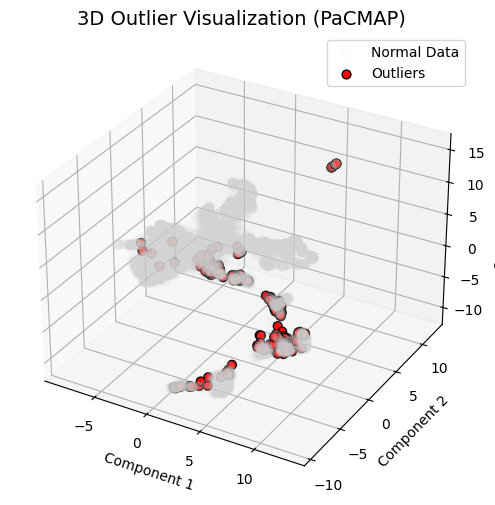

--- INFO EMBEDDING PaCMAP ---
Dimensioni input:  (7897, 37)
Dimensioni output: (7897, 3)
Outlier rilevati:  197
Punti normali:     7700


In [85]:
import pacmap
import matplotlib.pyplot as plt

# 1. Riduciamo il dataset a 3 dimensioni con PaCMAP
embedding_3d = pacmap.PaCMAP(n_components=3, random_state=42)
X_pacmap3d = embedding_3d.fit_transform(X)

# 2. Inizializziamo un grafico 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')

# 3. Plottiamo i dati normali (Inversione della maschera con ~)
ax.scatter(X_pacmap3d[~common_outliers, 0],
           X_pacmap3d[~common_outliers, 1],
           X_pacmap3d[~common_outliers, 2],
           c='lightgrey', alpha=0.05, s=40, label='Normal Data')

# 4. Plottiamo gli outlier comuni
ax.scatter(X_pacmap3d[common_outliers, 0],
           X_pacmap3d[common_outliers, 1],
           X_pacmap3d[common_outliers, 2],
           c='red', alpha=1, s=40, edgecolors='black', label='Outliers')

# 5. Etichette e legenda
ax.set_title('3D Outlier Visualization (PaCMAP)', fontsize=14)
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(loc='best')

plt.show()

# Nota: PaCMAP è un metodo non lineare e NON fornisce
# la varianza spiegata come PCA. Possiamo però stampare
# alcune informazioni sull'embedding.
print("--- INFO EMBEDDING PaCMAP ---")
print(f"Dimensioni input:  {X.shape}")
print(f"Dimensioni output: {X_pacmap3d.shape}")
print(f"Outlier rilevati:  {common_outliers.sum()}")
print(f"Punti normali:     {(~common_outliers).sum()}")

## Reason for why we decided to remove them

Trying to accommodate or impute this 1% introduces unnecessary pipeline complexity, risks distorting the natural probability distributions, and threatens the accuracy of standard algorithms, making their outright removal the most efficient and statistically safe choice.

Given that we have not chosen the outliers only based on one algorithm which could have falsly classified a point as outlier based on the limitation of that particular algorithm, and instead we have identified the 76 outlier points from the intersection of the results of diverse outlier detection algorithms, we have decided to remove these data points from our analysis.

In [86]:
print('before', df.shape)
df.drop(df[common_outliers].index, inplace=True)
print('after', df.shape)

before (7897, 37)
after (7700, 37)


### Write the new dataset with the outliers removed to a csv file for further analysis

In [87]:
df.to_csv(r"..\Dataset\dataset_module_one_DM2.csv", index=False)